# <div style="color: #00bbff">**Visión por Computadora**<div>

## <div style= "color:#00bbff">**Conceptos básicos de imágenes**<div>

La visión por computadora es un campo científico interdisciplinario que se ocupa de cómo las computadoras pueden obtener una comprensión de alto nivel a partir de imágenes o videos digitales. Desde la perspectiva de la ingeniería, busca comprender y automatizar tareas que el sistema visual humano puede realizar.

Una imagen es una digitalización del mundo real. Cada imagen consta de píxeles que son pequeños cuadrados llenos de un color.

![image.png](assets/cv-img-01.png)

![image.png](assets/cv-img-02.png)

Así vemos una imagen digital. Pero, ¿cómo se ve en una computadora? ¿Qué obtiene y cómo procesa la entrada? Para una computadora, una imagen es una función bidimensional 𝑓(𝑥,𝑦) ,  donde x y y son coordenadas espaciales y la amplitud de f en cualquier par de  coordenadas (x , y) es llamada la intensidad o nivel de gris.



![image.png](assets/cv-img-03.png)

Las imágenes digitales son básicamente matrices, a los ojos de una computadora donde 'x' es la fila, 'y' las columnas y f(x,y) la intensidad en esas coordenadas

In [1]:
import cv2 #Libreria open cv para imagenes
# from google.colab.patches import cv2_imshow # patch de google por que cv2 grafica en ventana emergente
from matplotlib import pyplot as plt #librería de visualización
import numpy as np #librería de matrices

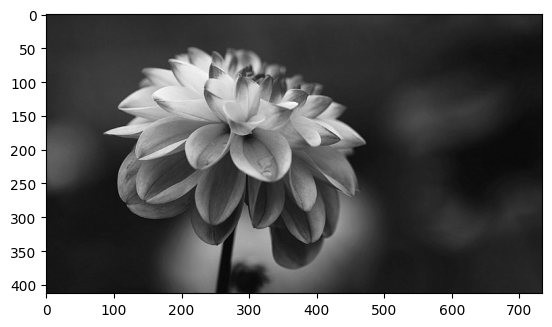

In [2]:
# Leer imagen, el cero es para que sea en escala de grises
# img_gray = cv2.imread('/content/imagen.jpg',0) # Carga en entorno de Google Colab
img_gray = cv2.imread("imagen.jpg",0)
# Visualizar imagen
# cv2_imshow(img_gray) # Para uso con Google Colab
plt.imshow(img_gray, cmap='gray') # Para uso con matplotlib

In [3]:
print(f"La imagen monocromática es una matriz de dimensiones: {img_gray.shape}")
print(f"La matriz imagen se ve: \n {img_gray}")

La imagen monocromática es una matriz de dimensiones: (413, 734)
La matriz imagen se ve: 
 [[42 41 41 ... 41 42 41]
 [41 41 41 ... 41 41 41]
 [40 40 40 ... 41 41 41]
 ...
 [21 21 21 ... 40 39 39]
 [20 20 20 ... 40 40 39]
 [20 19 19 ... 41 40 40]]


Se observa que es una matriz de diversos numeros que representan la intensidad en las distintas filas y columnas, por ejemplo vamos a imprimir y graficar los primeros pixeles

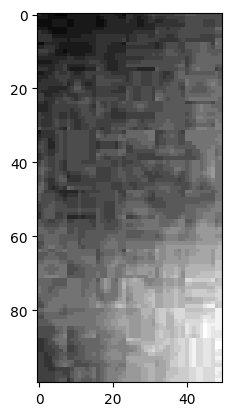

La imagen recortada es una matriz de dimensiones: (100, 50)
La matriz recortada se ve: 
 [[42 41 41 ... 45 45 45]
 [41 41 41 ... 45 45 45]
 [40 40 40 ... 44 45 45]
 ...
 [44 44 44 ... 56 58 57]
 [44 44 44 ... 56 57 57]
 [44 44 44 ... 56 58 58]]


In [4]:
#Tomamos una porción de la imagen de la fila cero a la 100 y columna 0 a 50
img_recorte = img_gray[0:100, 0:50]
#Creamos una figura en matplotlib
plt.figure()
#Todas las imagenes monocromaticas se deben visualizar en plt con el mapa gris
plt.imshow(img_recorte,cmap="gray")
plt.show()
print(f'La imagen recortada es una matriz de dimensiones: {img_recorte.shape}')
print(f'La matriz recortada se ve: \n {img_recorte}')

En las imágenes digitales típicas, cada píxel consta de un número entero de 8 bits, lo que genera 256 estados posibles, es decir que en la matriz vamos a encontrar numeros de 0 a 255 y su tipo de dato es uint8:

In [5]:
print(f'Tipo de datos de la imagen {img_gray.dtype}')

Tipo de datos de la imagen uint8


![image.png](assets/cv-img-04.png)

Las imagenes a color tienen para cada píxel tres numeros, en el espacio de color RGB que es el más usado cada numero representa la intensidad del Rojo (Red), Verde (Green) Y Azul (Blue) que componen la imagen.

A esto se le llaman canales.

![image.png](assets/cv-img-05.png)

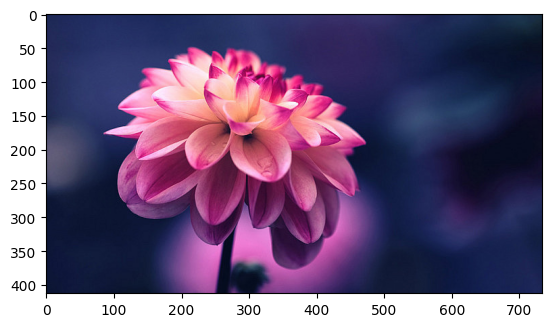

In [6]:
# img = cv2.imread("/content/imagen.jpg")
img = cv2.imread("imagen.jpg")

#cv2_imshow(img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [ ]:
print('Como se ve ahora tenemos la tercera dimensión que nos indica que es de 3 canales')
print(img.shape)

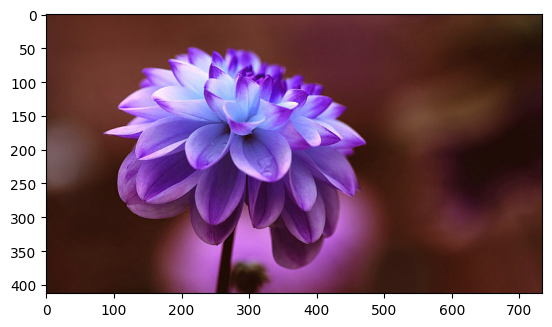

In [8]:
#Graficar la imagen con matplotlib
plt.figure()
plt.imshow(img)
plt.show()

La librería opencv tiene invertidos los canales azul y rojo, es decir que son imagenes BGR, por eso para visualizarlas con cualquier otra librería debemos hacer la conversión de BGR a RGB


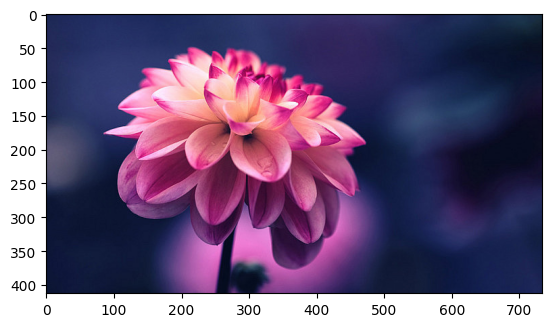

In [9]:
img_RGB = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Conversión BGR a RGB
plt.figure()
plt.imshow(img_RGB)
plt.show()

Observemos el mismo recorte que hicimos en la imagen monocromática:


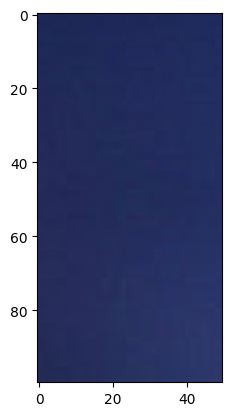

La imagen recortada es una matriz de dimensiones: (100, 50, 3)
La matriz recortada se ve: 
 [[[ 32  40  87]
  [ 31  39  86]
  [ 31  39  86]
  ...
  [ 31  43  93]
  [ 30  44  93]
  [ 30  44  93]]

 [[ 31  39  86]
  [ 31  39  86]
  [ 31  39  86]
  ...
  [ 31  43  93]
  [ 30  44  93]
  [ 30  44  93]]

 [[ 30  38  85]
  [ 30  38  85]
  [ 30  38  85]
  ...
  [ 30  42  92]
  [ 31  43  93]
  [ 31  43  93]]

 ...

 [[ 35  42  84]
  [ 35  42  84]
  [ 35  42  86]
  ...
  [ 44  54 105]
  [ 46  56 107]
  [ 45  55 106]]

 [[ 35  42  84]
  [ 35  42  84]
  [ 35  42  86]
  ...
  [ 44  54 105]
  [ 45  55 106]
  [ 45  55 106]]

 [[ 35  42  84]
  [ 35  42  84]
  [ 35  42  86]
  ...
  [ 44  54 105]
  [ 46  56 107]
  [ 46  56 107]]]


In [10]:
#Tomamos una porción de la imagen de la fila cero a la 100 y columna 0 a 50
img_rgb_recorte = img_RGB[0:100, 0:50]
#Creamos una figura en matplotlib
plt.figure()
#Todas las imagenes monocromaticas se deben visualizar en plt con el mapa gris
plt.imshow(img_rgb_recorte,cmap="gray")
plt.show()
print(f'La imagen recortada es una matriz de dimensiones: {img_rgb_recorte.shape}')
print(f'La matriz recortada se ve: \n {img_rgb_recorte}')

Por cada pixel tengo 3 numeros, miremos el primer pixel (0,0) para comprobarlo

In [11]:
print(img_RGB[0,0])

[32 40 87]


si se quiere extraer el canal especifico se agrega a las coordenadas un nuevo número que refleja el canal

In [12]:
print(f'Color rojo de la coordenada 0,0 : {img_RGB[0,0,0]}')
print(f'Color verde de la coordenada 0,0 : {img_RGB[0,0,1]}')
print(f'Color azul de la coordenada 0,0 : {img_RGB[0,0,2]}')

Color rojo de la coordenada 0,0 : 32
Color verde de la coordenada 0,0 : 40
Color azul de la coordenada 0,0 : 87


## <div style="color:#00bbff" >**Filtrado de imágenes**</div>

El filtrado de imágenes, en el contexto de la visión por computadora, se refiere a un proceso de modificar o mejorar una imagen aplicando un algoritmo específico o un conjunto de operaciones matemáticas a sus píxeles. El objetivo del filtrado de imágenes es manipular la imagen de tal manera que ciertas características se vuelvan más prominentes, lo que facilita la extracción de información relevante o la mejora de la calidad general de la imagen.
Los filtros de imagen suelen estar representados por una pequeña matriz o kernel, que se desliza sobre toda la imagen.

![image.png](assets/cv-img-06.png)

Para filtrado lineal, la respuesta  es dada por la suma de  productos de los coeficientes  del filtro y los correspondientes  pixeles directamente bajo el kernel. A esta operación se le conoce como convolución


En esencia, la convolución implica combinar dos funciones para producir una tercera función. En el procesamiento de imágenes, una de estas funciones es la imagen de entrada y la otra es una matriz más pequeña llamada núcleo o filtro. El kernel contiene valores numéricos que definen el comportamiento del filtro. El proceso implica deslizar el núcleo sobre la imagen, multiplicar sus valores con los valores de píxeles correspondientes en la imagen y sumar los resultados. Luego, esta suma se coloca en una ubicación específica de la imagen de salida.

En el contexto de la **convolución 1D**, nuestra entrada consta de una matriz unidimensional, a menudo denominada vector de características.

![image.png](assets/cv-img-07.png)

Si se observa esta operación hará que la salida sea más pequeña que la imagen original para eso se aplica padding o relleno que es agregar números a los extremos de la matriz original para que el kernel tenga con quien operarse y la imagen resultante sea del mismo tamaño de la original

![image.png](assets/cv-img-08.png)

Para la convolución 2D el proceso es el mismo y coloco el resultado en donde estaría el centro del filtro al momento de la operación

![image.png](assets/cv-img-09.png)

EJEMPLO: una imagen en escala de grises de 8 bits con una cuadrícula de 5x5. Los valores oscilan entre 0 y 255.

![image.png](assets/cv-img-10.png)

Y tenemos un kernel aleatorio de 3x3:


![image.png](assets/cv-img-11.png)

Cuando aplicamos el kernel a la entrada:

(-1*170)+(0*245)+(1*0)+(2*234)+(1*42)+(2*64)+(1*32)+(-2*53)+ (0*128)=394

![image.png](assets/cv-img-12.png)

Reemplazamos el píxel central con el valor calculado. Luego, movemos el kernel uno por uno (de arriba a la izquierda a abajo a la derecha) y hacemos los cálculos nuevamente.

Usamos relleno nuevamente para los píxeles del borde.

![image.png](assets/cv-img-13.png)

### <div style="color:#00bbff">**Filtros** <div>

La versatilidad de los filtros de imágenes cobra vida a través de su variedad de operaciones. Cada operación tiene un propósito distinto, moldeando la estética de la imagen o facilitando un análisis más profundo.

Filtros de suavizado

Filtros de afilado

Filtros de mejora de bordes

**Filtro de suavizado (Blurring)**

* 	Reemplazar el valor de un pixel por el promedio de los niveles de grises de los vecinos,  reduce las transiciones abruptas o muy marcadas de los niveles de grises.
* Transiciones fuertes:
  * Ruido aleatorio en una imagen (dada su naturaleza de “sharp” entre niveles de gris)
  * 	Bordes de los objetos en la imagen también son caracterizados por transiciones
“sharp” de intensidad.

 Por lo tanto, el suavizado reduce ruidos (deseable) y difumina los bordes (indeseable)


![image.png](assets/cv-img-14.png)

El promedio pesado es el mismo gaussiano

![image.png](assets/cv-img-15.png)

La extracción de bordes o **sharpenning** busca lo opuesto al suavizado, es decir que busca resaltar discontinuidades

![image.png](assets/cv-img-16.png)

![image.png](assets/cv-img-17.png)

**Filtros Laplacianos**

![image.png](assets/cv-img-18.png)

En open cv la convolución se realiza con la función cv2.filter2D

In [ ]:
#Convolución en imágen a color
#Matriz de kernel laplaciano
kernel=np.array([[1,1,1],
                 [1,-8,1],
                  [1,1,1]])
#Convolución entre la imágen y el kernel. El segundo argumento es 'ddepth' (profundidad/tipo de dato de
#la imagen de salida); -1 significa 'igual profundidad que la imagen de entrada'. OpenCV aplica el kernel
#a cada canal automáticamente, sin importar el valor de ddepth.
convolucion= cv2.filter2D(img_RGB, -1, kernel)
plt.figure()
plt.imshow(convolucion)
plt.show()

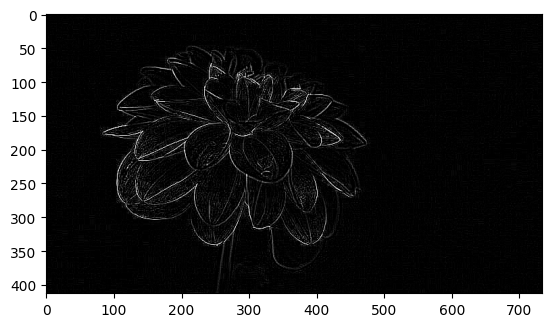

In [14]:
#Convolución en escala de grises
kernel=np.array([[1,1,1],
                 [1,-8,1],
                  [1,1,1]])
convolucion= cv2.filter2D(img_gray, -1, kernel)
plt.figure()
plt.imshow(convolucion,cmap="gray")
plt.show()